In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gym_exercises_kaggle = pd.read_csv('datasets/gym_exercises.csv')
gym_exercises_kaggle.head()

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [5]:
#Exploring dataset 1 - exercises.csv
unique_exercises = gym_exercises_kaggle.drop_duplicates(subset='Title').copy()
print(f"Total exercise entries: {len(gym_exercises_kaggle)}")
print(f"Unique exercises: {len(unique_exercises)}")
print(f"Number of columns: {gym_exercises_kaggle.shape[1]}")

#Unique muscle groups
exercises_bodyparts = unique_exercises['BodyPart'].value_counts()
print(f"Unique muscle groups: {len(exercises_bodyparts)}")

#How many have descriptions and bodyparts?
exercises_with_descriptions_and_bodyparts = unique_exercises[unique_exercises['Desc'].notna() & unique_exercises['BodyPart'].notna()].shape[0]
print(f"Exercises with descriptions and bodyparts: {exercises_with_descriptions_and_bodyparts}")

Total exercise entries: 2918
Unique exercises: 2909
Number of columns: 9
Unique muscle groups: 17
Exercises with descriptions and bodyparts: 1359


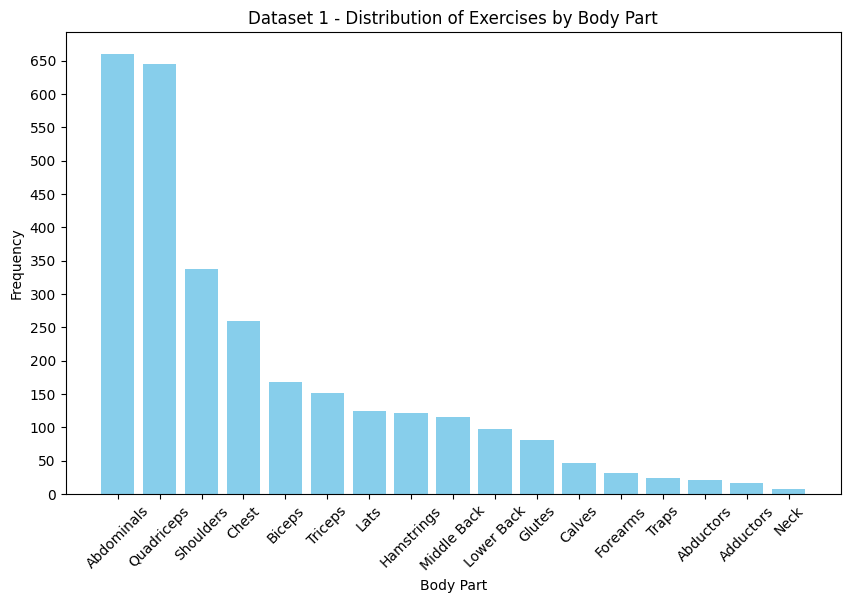

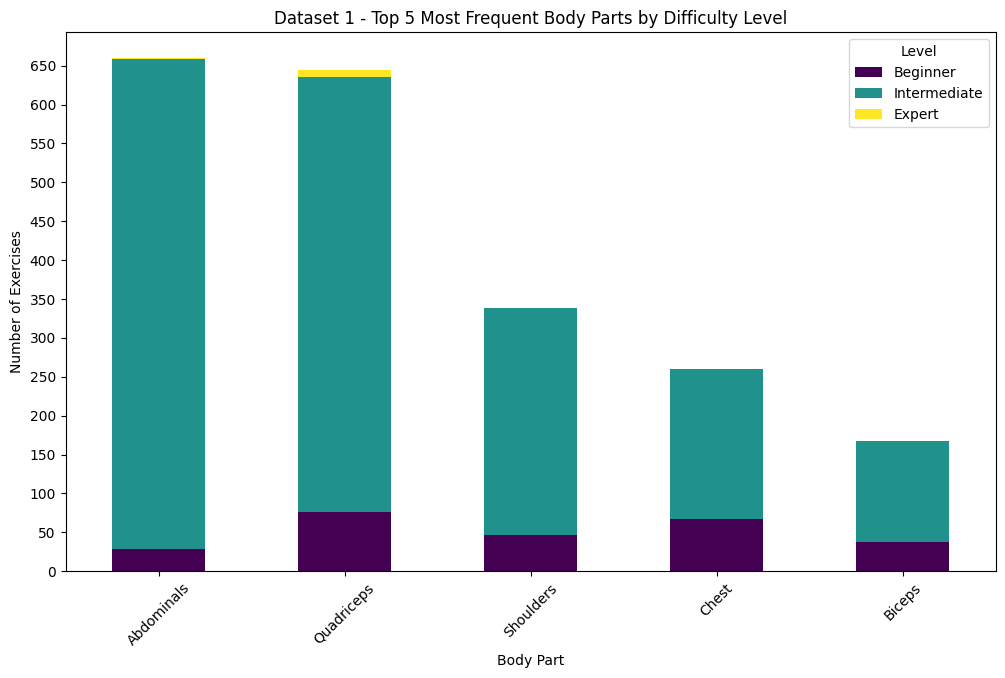

In [ ]:
#For exercises dataset
# Count the frequency of exercises for each body part
plt.figure(figsize=(10, 6))
plt.bar(exercises_bodyparts.index, exercises_bodyparts.values, color='skyblue')

plt.title('Dataset 1 - Distribution of Exercises by Body Part')
plt.xlabel('Body Part')
plt.ylabel('Frequency')

plt.xticks(rotation=45)
plt.yticks(np.arange(0, max(exercises_bodyparts.values) + 5, 50))

plt.savefig('plot_exercises_bodyparts.png', dpi=150, bbox_inches='tight', facecolor='#F8FBF9')

# Top 5 body parts in the same order as the first plot (descending frequency)
difficulty_levels_sorted = ['Beginner', 'Intermediate', 'Expert']
top5_bodyparts = exercises_bodyparts.head(5)

top_muscle_groups = unique_exercises.groupby(['BodyPart', 'Level']).size().unstack().fillna(0)
top_muscle_groups = top_muscle_groups.reindex(columns=difficulty_levels_sorted, fill_value=0)
top_muscle_groups = top_muscle_groups.loc[top5_bodyparts.index]

top_muscle_groups.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Dataset 1 - Top 5 Most Frequent Body Parts by Difficulty Level')
plt.xlabel('Body Part')
plt.ylabel('Number of Exercises')

plt.xticks(rotation=45)
plt.yticks(np.arange(0, max(top_muscle_groups.sum(axis=1)) + 5, 50))
plt.savefig('visualizations/plot_exercises_muscle_groups.png', dpi=150, bbox_inches='tight', facecolor='#F8FBF9')
plt.show()

In [30]:
programs = pd.read_csv('datasets/programs_detailed_boostcamp_kaggle.csv')
print(programs.shape)
print(programs.dtypes)
print(programs.head(3))
print(programs['goal'].head())

(605033, 16)
title                      str
description                str
level                      str
goal                       str
equipment                  str
program_length         float64
time_per_workout       float64
week                   float64
day                    float64
number_of_exercises    float64
exercise_name              str
sets                   float64
reps                   float64
intensity              float64
created                    str
last_edit                  str
dtype: object
                            title  \
0  Weightlifting Mobility program   
1  Weightlifting Mobility program   
2  Weightlifting Mobility program   

                                         description  \
0  This program is designed to help athletes succ...   
1  This program is designed to help athletes succ...   
2  This program is designed to help athletes succ...   

                                               level  \
0  ['Beginner', 'Novice', 'Intermediate', 'Adva

In [70]:
import ast

#EXPLORING CLEANED PROGRAM DATASET

# ── Deduplicate to one row per program ────────────────────────────────────────
# Since each row is an exercise entry, group by title to get unique programs
programs_unique = programs.drop_duplicates(subset='title').copy()
print(f"Total exercise entries: {len(programs)}")
print(f"Unique programs: {len(programs_unique)}")

# ── Parse goal column ─────────────────────────────────────────────────────────
def parse_str_to_list(val):
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except:
        return [g.strip() for g in str(val).split(',')]
    
def normalize_level(val):
    levels = parse_str_to_list(val)

    # Treat Novice as Beginner
    normalized = []
    for l in levels:
        l = l.strip()
        if l == 'Novice':
            l = 'Beginner'
        if l and l not in normalized:  # deduplicate after normalizing
            normalized.append(l)
    return normalized

programs_unique['goal_list'] = programs_unique['goal'].apply(parse_str_to_list)
programs_unique['num_goals'] = programs_unique['goal_list'].apply(len)

# Take the minimum level (most accessible audience)
level_order = ['Beginner', 'Intermediate', 'Advanced']

def assign_primary_level(level):
    for l in level_order:
        if l in level:
            return l
    return 'Unknown'

programs_unique['level'] = programs_unique['level'].apply(normalize_level)
programs_unique['level_primary'] = programs_unique['level'].apply(assign_primary_level)
print(programs_unique['level_primary'].value_counts())

programs_unique.to_csv('datasets/programs_cleaned.csv', index=False)

Total exercise entries: 605033
Unique programs: 2598
level_primary
Beginner        1481
Intermediate     988
Advanced         121
Unknown            8
Name: count, dtype: int64



Unique goal types: 7
Avg goals per program: 1.91

Goal counts:
goal_list
Bodybuilding             1723
Muscle & Sculpting        936
Powerbuilding             905
Athletics                 539
Powerlifting              494
Bodyweight Fitness        322
Olympic Weightlifting      39
Name: count, dtype: int64


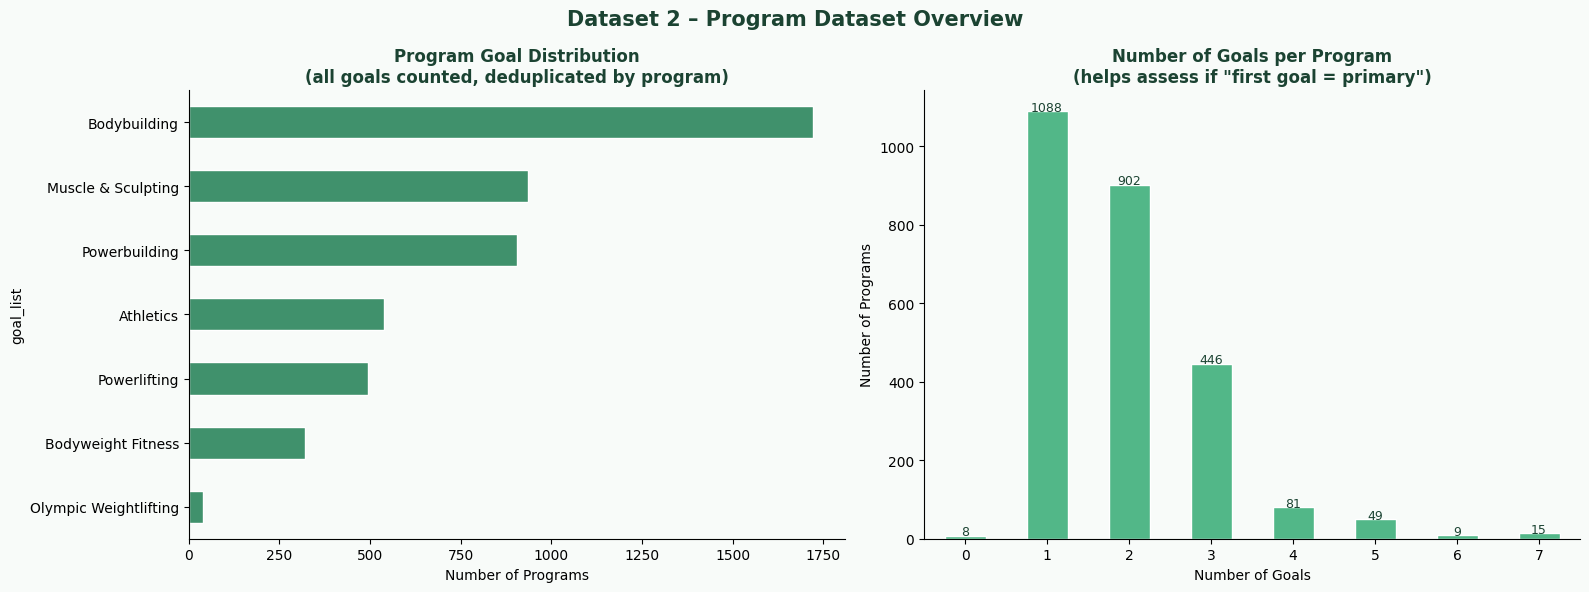

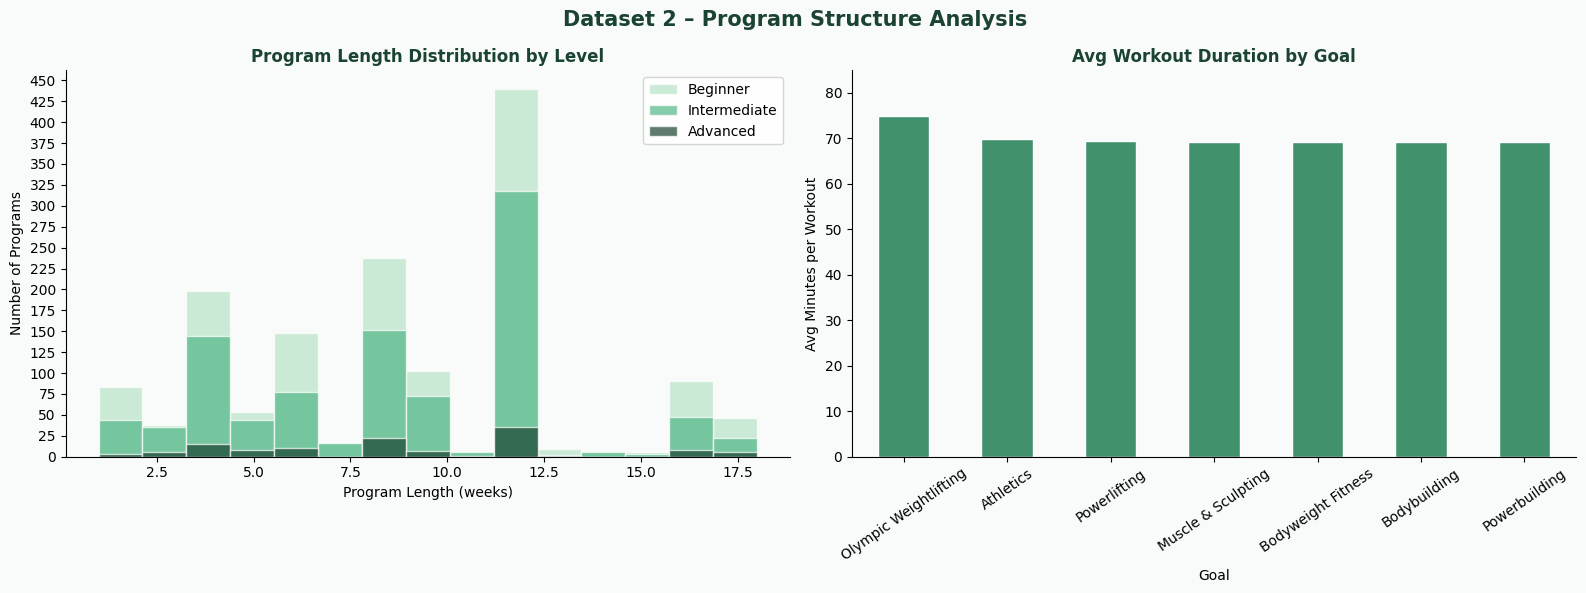

In [ ]:
# Explode for counting
goals_exploded = programs_unique.explode('goal_list')
goal_counts = goals_exploded['goal_list'].value_counts()

print(f"\nUnique goal types: {goals_exploded['goal_list'].nunique()}")
print(f"Avg goals per program: {programs_unique['num_goals'].mean():.2f}")
print(f"\nGoal counts:\n{goal_counts}")

# ── Plot 1: Goal distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#F8FBF9')

goal_counts.plot(kind='barh', ax=axes[0], color='#40916C', edgecolor='white')
axes[0].set_title('Program Goal Distribution\n(all goals counted, deduplicated by program)',
                  fontweight='bold', color='#1B4332')
axes[0].set_xlabel('Number of Programs')
axes[0].invert_yaxis()
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_facecolor('#F8FBF9')

# ── Plot 2: Goals per program ─────────────────────────────────────────────────
goal_freq = programs_unique['num_goals'].value_counts().sort_index()
goal_freq.plot(kind='bar', ax=axes[1], color='#52B788', edgecolor='white')
axes[1].set_title('Number of Goals per Program\n(helps assess if "first goal = primary")',
                  fontweight='bold', color='#1B4332')
axes[1].set_xlabel('Number of Goals')
axes[1].set_ylabel('Number of Programs')
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_facecolor('#F8FBF9')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.5,
                 str(int(p.get_height())), ha='center', fontsize=9, color='#1B4332')

plt.suptitle('Dataset 2 – Program Dataset Overview', fontsize=15,
             fontweight='bold', color='#1B4332')
plt.tight_layout()
plt.savefig('visualizations/plot_program_goals.png', dpi=150, bbox_inches='tight', facecolor='#F8FBF9')
plt.show()

# ── Plot 3: Program length distribution by level ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#F8FBF9')

level_order = ['Beginner', 'Intermediate', 'Advanced']
level_colors = {'Beginner': '#B7E4C7', 'Intermediate': '#52B788', 'Advanced': '#1B4332'}

for level in level_order:
    subset = programs_unique[programs_unique['level_primary'] == level]['program_length'].dropna()
    axes[0].hist(subset, bins=15, alpha=0.7, label=level,
                 color=level_colors.get(level, 'gray'), edgecolor='white')

axes[0].set_title('Program Length Distribution by Level', fontweight='bold', color='#1B4332')
axes[0].set_yticks(np.arange(0, axes[0].get_ylim()[1] + 5, 25))
axes[0].set_xlabel('Program Length (weeks)')
axes[0].set_ylabel('Number of Programs')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_facecolor('#F8FBF9')

# ── Plot 4: Avg time per workout by goal ──────────────────────────────────────
# Join goals back to time_per_workout
goals_with_time = programs_unique[['goal_list', 'time_per_workout']].explode('goal_list')
avg_time = goals_with_time.groupby('goal_list')['time_per_workout'].mean().sort_values(ascending=False)

avg_time.plot(kind='bar', ax=axes[1], color='#40916C', edgecolor='white')
axes[1].set_title('Avg Workout Duration by Goal', fontweight='bold', color='#1B4332')
axes[1].set_xlabel('Goal')
axes[1].set_ylabel('Avg Minutes per Workout')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylim(0, avg_time.max() + 10)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_facecolor('#F8FBF9')

plt.suptitle('Dataset 2 – Program Structure Analysis', fontsize=15,
             fontweight='bold', color='#1B4332')
plt.tight_layout()
plt.savefig('visualizations/plot_program_structure.png', dpi=150, bbox_inches='tight', facecolor='#F8FBF9')
plt.show()

In [67]:
# How many rows per program on average?
programs_unique = programs.drop_duplicates(subset='title').copy()
print(f"Total exercise entries: {len(programs)}")
print(f"Unique programs: {len(programs_unique)}")

rows_per_program = programs.groupby('title').size()
print(f"Unique programs: {len(rows_per_program)}")
print(f"Avg rows per program: {rows_per_program.mean():.1f}")
print(f"Min rows: {rows_per_program.min()}, Max rows: {rows_per_program.max()}")
print(f"Weeks range: {programs['week'].min()} - {programs['week'].max()}")
print(f"Days range: {programs['day'].min()} - {programs['day'].max()}")

Total exercise entries: 605033
Unique programs: 2598
Unique programs: 2598
Avg rows per program: 232.9
Min rows: 1, Max rows: 5040
Weeks range: 1.0 - 18.0
Days range: 1.0 - 10.0


In [68]:
programs_unique.head()

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
0,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Knee-to-wall ankle dorsiflexion test,3.0,-180.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
325,Lyle McDonald Routine (Strength/Hypertrophy Vers),IMPORTANT: THIS IS NOT THE ORIGINAL LYLE MCDON...,[],[],Full Gym,12.0,90.0,1.0,1.0,6.0,Bench Press (Barbell),5.0,9.0,8.0,2025-05-16 11:23:00,2025-06-27 02:28:00
613,"Jeff Nippard’s Fundamentals, Upper&Lower Split...",Primary goal is to establish a solid strength ...,"['Intermediate', 'Novice']","['Bodybuilding', 'Powerbuilding', 'Muscle & Sc...",Full Gym,8.0,60.0,1.0,1.0,7.0,Bench Press (Barbell),3.0,8.0,8.0,2024-07-15 03:29:00,2025-06-27 02:11:00
837,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,['Beginner'],['Bodybuilding'],Full Gym,7.0,90.0,1.0,1.0,4.0,Squat (Barbell),1.0,15.0,8.0,2025-04-06 03:06:00,2025-06-18 08:29:00
977,Rampage,Pack on muscle and gain strength through this ...,"['Intermediate', 'Advanced']","['Bodybuilding', 'Powerbuilding']",Full Gym,18.0,70.0,1.0,1.0,5.0,Bench Press (Barbell),3.0,14.0,9.0,2025-04-01 04:15:00,2025-06-23 05:15:00


JSON DATASET FROM GIT REPO

In [ ]:
import requests
import json

url = "https://raw.githubusercontent.com/yuhonas/free-exercise-db/main/dist/exercises.json"
response = requests.get(url)
exercises = response.json()

# Save as JSON directly, no list-to-string conversion issues
with open('datasets/exercises_free_db.json', 'w') as f:
    json.dump(exercises, f, indent=2)

print(f"Total exercises saved: {len(exercises)}")

Total exercises saved: 873


In [6]:
with open('datasets/exercises_free_db.json', 'r') as f:
    exercises = json.load(f)

df_exercises = pd.DataFrame(exercises).drop(columns=['images'])
df_exercises.columns.tolist()

['name',
 'force',
 'level',
 'mechanic',
 'equipment',
 'primaryMuscles',
 'secondaryMuscles',
 'instructions',
 'category',
 'id']

In [7]:
df_exercises.head(2)

,name,force,level,mechanic,equipment,primaryMuscles,secondaryMuscles,instructions,category,id
0,3/4 Sit-Up,pull,beginner,compound,body only,[abdominals],[],[Lie down on the floor and secure your feet. Y...,strength,3_4_Sit-Up
1,90/90 Hamstring,push,beginner,NaN,body only,[hamstrings],[calves],"[Lie on your back, with one leg extended strai...",stretching,90_90_Hamstring


In [14]:
# ── Basic stats ───────────────────────────────────────────────────────────────
print(f"Total exercises: {len(df_exercises)}")
print(f"Unique exercises: {df_exercises['name'].nunique()}")
print(f"\nNull values:\n{df_exercises.isnull().sum()}")
print(f"\nLevel distribution:\n{df_exercises['level'].value_counts()}")
print(f"\nCategory distribution:\n{df_exercises['category'].value_counts()}")
print(f"\nEquipment distribution:\n{df_exercises['equipment'].value_counts()}")
print(f"\nForce distribution:\n{df_exercises['force'].value_counts()}")
print(f"\nMechanic distribution:\n{df_exercises['mechanic'].value_counts()}")

# Primary muscles (explode since it's a list)
df_muscles = df_exercises.explode('primaryMuscles')
print(f"\nUnique primary muscles: {df_muscles['primaryMuscles'].nunique()}")
print(f"\nPrimary muscle distribution:\n{df_muscles['primaryMuscles'].value_counts()}")

#Mechanics - to see if important
print(f"\nUnique mechanics: {df_exercises['mechanic'].nunique()}")
print(f"\nMechanic distribution:\n{df_exercises['mechanic'].value_counts()}")

# Instruction length (useful to know for IR — more instructions = richer text)
df_exercises['instruction_count'] = df_exercises['instructions'].apply(len)
print(f"\nAvg instruction steps: {df_exercises['instruction_count'].mean():.1f}")
print(f"Min: {df_exercises['instruction_count'].min()}, Max: {df_exercises['instruction_count'].max()}")

Total exercises: 873
Unique exercises: 873

Null values:
name                  0
force                29
level                 0
mechanic             87
equipment            77
primaryMuscles        0
secondaryMuscles      0
instructions          0
category              0
id                    0
instruction_count     0
dtype: int64

Level distribution:
level
beginner        523
intermediate    293
expert           57
Name: count, dtype: int64

Category distribution:
category
strength                 581
stretching               123
plyometrics               61
powerlifting              38
olympic weightlifting     35
strongman                 21
cardio                    14
Name: count, dtype: int64

Equipment distribution:
equipment
barbell          170
dumbbell         123
other            122
body only        111
cable             81
machine           67
kettlebells       53
bands             20
medicine ball     17
exercise ball     12
foam roll         11
e-z curl bar       9
Name

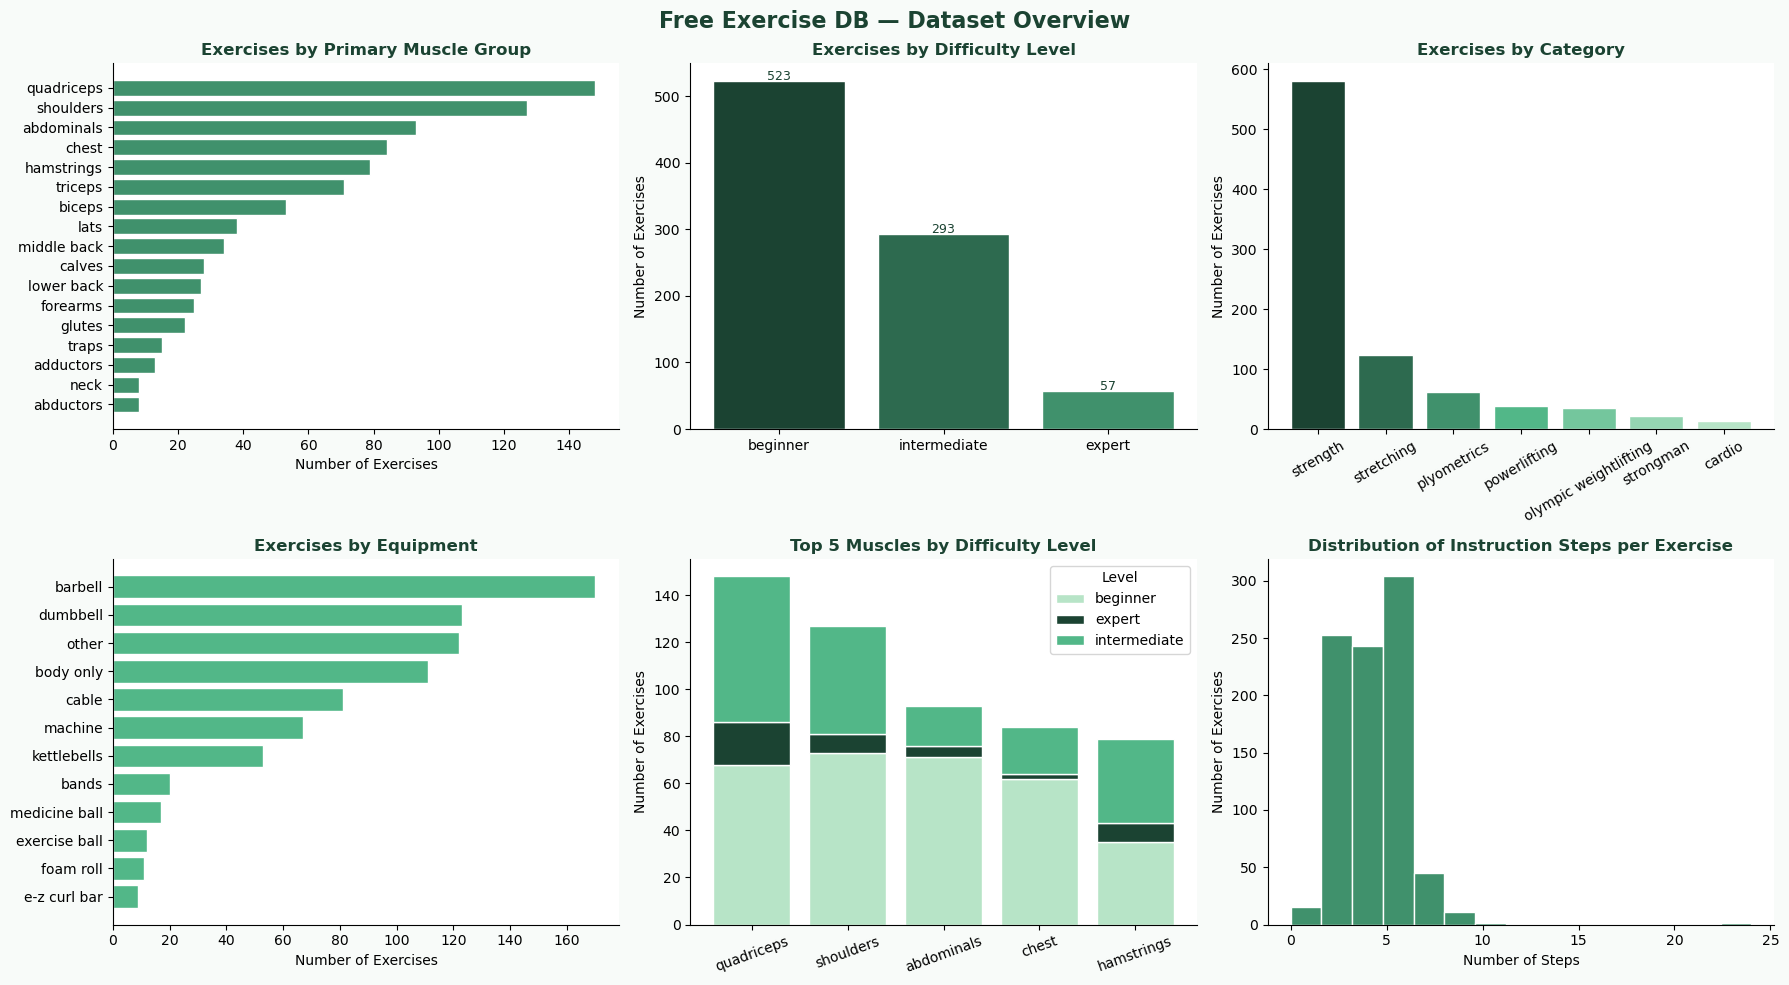

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#F8FBF9')
COLORS = ["#1B4332","#2D6A4F","#40916C","#52B788","#74C69D","#95D5B2","#B7E4C7"]

# Plot 1: Primary muscle group distribution
muscle_counts = df_muscles['primaryMuscles'].value_counts()
axes[0,0].barh(muscle_counts.index, muscle_counts.values, color='#40916C', edgecolor='white')
axes[0,0].set_title('Exercises by Primary Muscle Group', fontweight='bold', color='#1B4332')
axes[0,0].set_xlabel('Number of Exercises')
axes[0,0].invert_yaxis()
axes[0,0].spines[['top','right']].set_visible(False)

# Plot 2: Level distribution
level_counts = df_exercises['level'].value_counts()
axes[0,1].bar(level_counts.index, level_counts.values, color=COLORS[:len(level_counts)], edgecolor='white')
axes[0,1].set_title('Exercises by Difficulty Level', fontweight='bold', color='#1B4332')
axes[0,1].set_ylabel('Number of Exercises')
axes[0,1].spines[['top','right']].set_visible(False)
for p in axes[0,1].patches:
    axes[0,1].text(p.get_x() + p.get_width()/2, p.get_height() + 1,
                   str(int(p.get_height())), ha='center', fontsize=9, color='#1B4332')

# Plot 3: Category distribution
cat_counts = df_exercises['category'].value_counts()
axes[0,2].bar(cat_counts.index, cat_counts.values, color=COLORS[:len(cat_counts)], edgecolor='white')
axes[0,2].set_title('Exercises by Category', fontweight='bold', color='#1B4332')
axes[0,2].set_ylabel('Number of Exercises')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].spines[['top','right']].set_visible(False)

# Plot 4: Equipment distribution
equip_counts = df_exercises['equipment'].value_counts()
axes[1,0].barh(equip_counts.index, equip_counts.values, color='#52B788', edgecolor='white')
axes[1,0].set_title('Exercises by Equipment', fontweight='bold', color='#1B4332')
axes[1,0].set_xlabel('Number of Exercises')
axes[1,0].invert_yaxis()
axes[1,0].spines[['top','right']].set_visible(False)

# Plot 5: Top 5 muscles by level (stacked bar)
top5_muscles = muscle_counts.head(5).index.tolist()
df_top5 = df_muscles[df_muscles['primaryMuscles'].isin(top5_muscles)]
pivot = df_top5.groupby(['primaryMuscles', 'level']).size().unstack(fill_value=0)
pivot = pivot.reindex(top5_muscles)
level_colors = {'beginner': '#B7E4C7', 'intermediate': '#52B788', 'expert': '#1B4332'}
bottom = pd.Series([0] * len(pivot), index=pivot.index)
for lvl in pivot.columns:
    axes[1,1].bar(pivot.index, pivot[lvl], bottom=bottom,
                  color=level_colors.get(lvl, 'gray'), edgecolor='white', label=lvl)
    bottom += pivot[lvl]
axes[1,1].set_title('Top 5 Muscles by Difficulty Level', fontweight='bold', color='#1B4332')
axes[1,1].set_ylabel('Number of Exercises')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].legend(title='Level')
axes[1,1].spines[['top','right']].set_visible(False)

# Plot 6: Instruction steps distribution
axes[1,2].hist(df_exercises['instruction_count'], bins=15, color='#40916C', edgecolor='white')
axes[1,2].set_title('Distribution of Instruction Steps per Exercise', fontweight='bold', color='#1B4332')
axes[1,2].set_xlabel('Number of Steps')
axes[1,2].set_ylabel('Number of Exercises')
axes[1,2].spines[['top','right']].set_visible(False)

plt.suptitle('Free Exercise DB — Dataset Overview', fontsize=16,
             fontweight='bold', color='#1B4332')
plt.tight_layout()
plt.savefig('plot_exercises_overview.png', dpi=150, bbox_inches='tight', facecolor='#F8FBF9')
plt.show()